In [7]:
import pandas as pd
import os
import pysam
import matplotlib.pyplot as plt
import json

## Load in PSV File and export

In [8]:
#QC checked good AZFc regions
errDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/QC/LocationFiles/AZFc_QC_File.csv").drop(columns=['Unnamed: 0'])

In [9]:
snpDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/DAZ_PSVs.csv")

In [10]:
psvDict={x:{} for x in set(snpDF['PSV'])}
for row in snpDF.index:
    psv = snpDF.at[row,'PSV']
    gntList = [x.strip() for x in snpDF.at[row,'Genotype and discriminated genes'].split('vs')]
    for x in gntList:
        newList = x.split()
        if '/' in newList[1]:
            dazNumerals = newList[1].split("DAZ")[1].split(")")[0].split("/")
            for daz in dazNumerals:
                 psvDict[psv]['DAZ'+str(daz)]=newList[0]
        else:
            dazName = newList[1].split("(")[1].split(")")[0]
            psvDict[psv][dazName]=newList[0]

In [11]:
#Reran after QC
#with open('/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/PSV_sequences.fasta','a+') as file:
#    for row in snpDF.index:
#        psv = snpDF.at[row,'PSV']
#        gntList = snpDF.at[row,'Genomic coordinate on chrY (GRCh38)'].split(",")
#        for dazCoordinate in (gntList):
#            daz = dazCoordinate.split(":")[0].strip()
#            start = int(dazCoordinate.split(":")[1])-50
#            end = int(dazCoordinate.split(":")[1])+50
    
#            sequence = ''.join(pysam.faidx('/LeeLab/referenceSequences/GRCh38_chrY.fasta', 'chrY:'+str(start)+'-'+str(end)).split()[1:])
#            sequenceName = (dazCoordinate.strip()+"_"+str(psv)+"_"+str(psvDict[psv][daz]))
#            file.write(">"+sequenceName+"\n")
#            file.write(sequence+"\n")
#file.close()

## Import blat alignments

In [12]:
import collections
psvAlleles=[]
myTempDictionary={}
directory = '/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/blatRuns/'
for file in os.listdir(directory):
    df = pd.read_csv(directory+file, sep='\t', skiprows=5, header=None)
    fileName = list(df[13])[0]
    for allele in set(list(df[9])):
        if allele in psvAlleles:
            continue
        else:
            psvAlleles.append(allele)
    myTempDictionary[fileName]={'DAZ1':0,'DAZ2':0,'DAZ3':0,'DAZ4':0}
    
    for line in set(df[15]):
        df2 = df[df[15]==line].copy()
        newDict = collections.Counter([x.split(":")[0] for x in df2[9]])
        for key in newDict.keys():
            myTempDictionary[fileName][key.split(":")[0]]+=1

In [13]:
myTempPlacementDictionary={}
directory = '/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/blatRuns/'
for file in os.listdir(directory):
    df = pd.read_csv(directory+file, sep='\t', skiprows=5, header=None)
    fileName = list(df[13])[0]
    myTempPlacementDictionary[fileName]={'DAZ1':{},'DAZ2':{},'DAZ3':{},'DAZ4':{}}

    dazGeneStart = int(fileName.split(":")[1].split("-")[0])-50

    for line in set(df[15]):
        psvCoordinate = dazGeneStart+int(line)
        df2 = df[df[15]==line].copy()

        for psv, orientation in zip(df2[9],df2[8]):
            daz = psv.split(":")[0]
            
            myTempPlacementDictionary[fileName][daz][psv]=str(psvCoordinate)+"_"+str(orientation)

In [9]:
file_path = "/LeeLab/HPRC/chromosomeY/Data/PSV_Hits_PerDAZGene.json"
#with open(file_path, "w") as json_file:
#    json.dump(myTempPlacementDictionary, json_file)

In [14]:
myDF = pd.DataFrame(data=myTempDictionary).T
myDF['contig']=[str(x.split(":")[0]) for x in myDF.index]
myDF['start']=[int(x.split(":")[1].split("-")[0]) for x in myDF.index]
myDF.sort_values(by=['contig','start'], inplace=True)

exondazDF=pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/HGSVC3_HPRC_CEPH_DAZ_RRM_CopyNumbers_Jan222026.csv').set_index("contig")

In [15]:
import ast
countDict={}
myDF['RRMs']='temp'
for row in myDF.index:
    contig = myDF.at[row,'contig']

    if contig in exondazDF.index:
    
        if contig in countDict:
            currentCount = countDict[contig]
            exonList = ast.literal_eval(str(exondazDF.at[contig,'exonList']))
            myDF.at[row,'RRMs']=exonList[currentCount+1]
            
            countDict[contig]+=1
    
        else:
            exonList = ast.literal_eval(str(exondazDF.at[contig,'exonList']))
            myDF.at[row,'RRMs']=exonList[0]
            countDict[contig]=0
    else:
        continue
        if str(contig) in errDF['contig']:
            print("ERROR")
        else:
            print(contig)
    

In [16]:
myDF['MaxCount']='temp'
for row in myDF.index:
    newDict={'DAZ1':int(myDF.at[row,'DAZ1']),
             'DAZ2':int(myDF.at[row,'DAZ2']),
             'DAZ3':int(myDF.at[row,'DAZ3']),
             'DAZ4':int(myDF.at[row,'DAZ4'])
            }

    maximumValue = max(newDict.values())
    goodKeys=[]
    for key,value in newDict.items():
        if value == maximumValue:
            goodKeys.append(key)

    if len(goodKeys)>1:
        print(row, goodKeys)
        myDF.at[row,'MaxCount']='/'.join(sorted(goodKeys))
    else:
        myDF.at[row,'MaxCount']=goodKeys[0]

HG002_chrY:23964743-24025941 ['DAZ3', 'DAZ4']
HG003_chrY:23632738-23693936 ['DAZ3', 'DAZ4']
HG005_chrY:24515260-24575123 ['DAZ3', 'DAZ4']
HG00658_chrY_random0000678:5868-37061 ['DAZ3', 'DAZ4']
HG01167_chrY:26103972-26169921 ['DAZ3', 'DAZ4']
HG01255_chrY:25981971-26043169 ['DAZ3', 'DAZ4']
HG01258_chrY:26094493-26155691 ['DAZ3', 'DAZ4']
HG01433_chrY_random0000683:176941-238141 ['DAZ3', 'DAZ4']
HG01530_chrY:24566801-24599866 ['DAZ1', 'DAZ2']
HG01530_chrY:26072094-26131960 ['DAZ3', 'DAZ4']
HG01890_chrY:24900117-24961322 ['DAZ3', 'DAZ4']
HG02145_chrY_random0000307:19797-40633 ['DAZ1', 'DAZ2']
HG02698_chrY:24435209-24503586 ['DAZ2', 'DAZ3']
HG02984_chrY:24901010-24966981 ['DAZ3', 'DAZ4']
HG03688_chrY:24672522-24722867 ['DAZ3', 'DAZ4']
HG04199_chrY:24704244-24754587 ['DAZ3', 'DAZ4']
NA19043_chrY:23807485-23857832 ['DAZ3', 'DAZ4']


In [17]:
#In case we want to filter by good color blocks only
goodSamplesKarol =errDF.copy()
goodContigs = set([x for x in goodSamplesKarol['contig']])

In [18]:
file_path = "/LeeLab/HPRC/chromosomeY/Data/PSV_Hits_PerDAZGene_GoodGenes.json"
with open(file_path, "r") as json_file:
    goodGeneIDs = json.load(json_file)

myDF1 = myDF.loc[goodGeneIDs.keys()].copy()

In [19]:
myDF2 = myDF1.loc[[x for x in myDF1.index if x.split(":")[0] in goodContigs and 'random' not in x]].copy()
myDF2['sample']=[x.split("_")[0] for x in myDF2['contig']]
#myDF2 = myDF.loc[[x for x in myDF.index if 'HG03456' not in x and 'NA12883' not in x and 'NA12884' not in x]].copy()

In [20]:
len(set(myDF2['contig']))

100

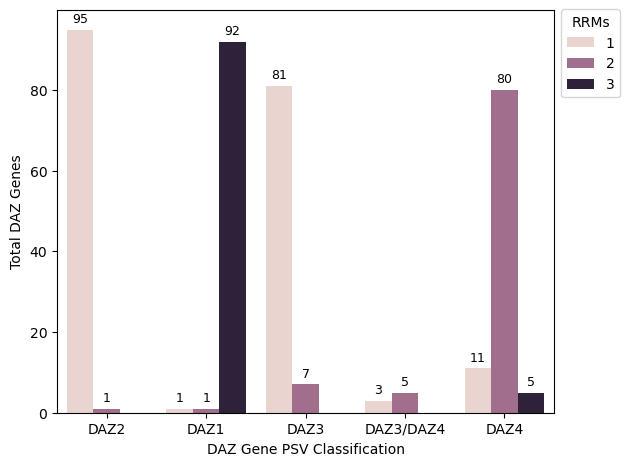

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(
    data=myDF2[myDF2['RRMs'].isin([1,2,3])],
    x="MaxCount",
    hue="RRMs"
)

plt.ylabel("Total DAZ Genes")
plt.xlabel("DAZ Gene PSV Classification")

# add counts on each bar
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{int(h)}",
            (p.get_x() + p.get_width()/2, h),
            ha="center", va="bottom",
            xytext=(0, 3), textcoords="offset points",
            fontsize=9
        )

plt.legend(loc='center left', bbox_to_anchor=(1, 0.893), title='RRMs')
plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DAZ_psv_barplot-Jan222026.pdf", bbox_inches="tight")
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DAZ_psv_barplot-Jan222026.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
#Reran after QC
#myDF2.to_csv("/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/DAZNames_PSV.csv")

In [19]:
psvList = [x+"_PSV" for x in snpDF['PSV']]
psvDF = pd.DataFrame(0, index=myDF2.index, columns=psvList)
psvAlleleDF = pd.DataFrame(0, index=myDF2.index, columns=sorted(psvAlleles))

directory = '/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/blatRuns/'
for file in os.listdir(directory):
    df = pd.read_csv(directory+file, sep='\t', skiprows=5, header=None)
    fileName = list(df[13])[0]
    if fileName in psvDF.index:
        for line in set(df[15]):
            df2 = df[df[15]==line].copy()
            psvList=[str(x.split("_")[1])+"_PSV" for x in df2[9]]
            psvList2 = [str(x) for x in df2[9]]
            tempDict = collections.Counter(psvList)
            tempDict2 = collections.Counter(psvList2)
            
            for key in tempDict.keys():
                psvDF.at[fileName, key]+=1

            for key,count in tempDict2.items():
                psvAlleleDF.at[fileName, key]+=count

psvDF['contig']=[str(x.split(":")[0]) for x in psvDF.index]
psvDF['start']=[int(x.split(":")[1].split("-")[0]) for x in psvDF.index]

In [20]:
len(set(psvDF['contig']))

100

In [21]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

from typing import List, Optional
from Bio import Phylo

def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample+"_chrY")
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

('HG02984_chrY', 'HG01890_chrY', 'HG02647_chrY', 'HG02666_chrY', 'HG02668_chrY', 'HG03225_chrY', 'NA19043_chrY', 'NA19384_chrY', 'HG005_chrY', 'NA18952_chrY', 'NA18983_chrY', 'HG02572_chrY', 'HG03248_chrY', 'HG03098_chrY', 'HG03050_chrY', 'NA19239_chrY', 'HG01074_chrY', 'HG01109_chrY', 'HG01106_chrY', 'NA19331_chrY', 'HG01252_chrY', 'HG01457_chrY', 'HG03065_chrY', 'HG02717_chrY', 'HG03471_chrY', 'HG02011_chrY', 'HG03371_chrY', 'HG02486_chrY', 'HG02965_chrY', 'HG03139_chrY', 'NA19443_chrY', 'NA19317_chrY', 'NA19347_chrY', 'NA20346_chrY', 'HG02145_chrY', 'HG02258_chrY', 'HG02953_chrY', 'HG03130_chrY', 'HG03521_chrY', 'HG02554_chrY', 'NA18879_chrY', 'HG03209_chrY', 'NA18522_chrY', 'NA19700_chrY', 'HG02055_chrY', 'NA19705_chrY', 'NA18612_chrY', 'NA18620_chrY', 'HG04157_chrY', 'NA18989_chrY', 'NA18971_chrY', 'NA18974_chrY', 'HG02040_chrY', 'NA20870_chrY', 'HG03710_chrY', 'HG01099_chrY', 'HG03579_chrY', 'NA21093_chrY', 'HG04187_chrY', 'HG03009_chrY', 'HG03942_chrY', 'HG01167_chrY', 'HG00140_

In [22]:
from pandas.api.types import CategoricalDtype
cat_type = CategoricalDtype(categories=phylogeneticOrder, ordered=True)
psvDF['contig'] = psvDF['contig'].astype(cat_type)
psvDF_sorted = psvDF.sort_values(['contig','start'])

psvDF_sorted2 = psvDF_sorted.loc[[x for x in psvDF_sorted.index if 'HG03456' not in x and 'random' not in x]].copy()
psvAlleleDF2 = psvAlleleDF.loc[[x for x in psvAlleleDF.index if 'HG03456' not in x and 'random' not in x]].copy()

print(len(psvDF_sorted2))
print(len(psvAlleleDF2))

382
382


In [23]:
changeNameDict={x:x+"_"+y for x,y in zip(myDF2.index, myDF2['MaxCount'])}
psvAlleleDF4 = psvAlleleDF2.rename(index=changeNameDict).copy()
psvDF_sorted2 = psvDF_sorted2.rename(index=changeNameDict)

In [24]:
psvDF_sorted3 = psvDF_sorted2[['I_PSV', 'II_PSV', 'III_PSV', 'IV_PSV', 'V_PSV', 'VI_PSV', 'VII_PSV',
       'VIII_PSV', 'IX_PSV', 'DAZI_PSV', 'DAZII_PSV', 'DAZIII_PSV',
       'o912/o913_PSV', 'Y-DAZ3_PSV', 'DAZV_PSV']].copy()

In [25]:
#psvDF_sorted3.to_csv('/PSV_Sample_DF.csv')
#psvAlleleDF.to_csv('/PSV_SampleAllele_DF.csv')

<Axes: >

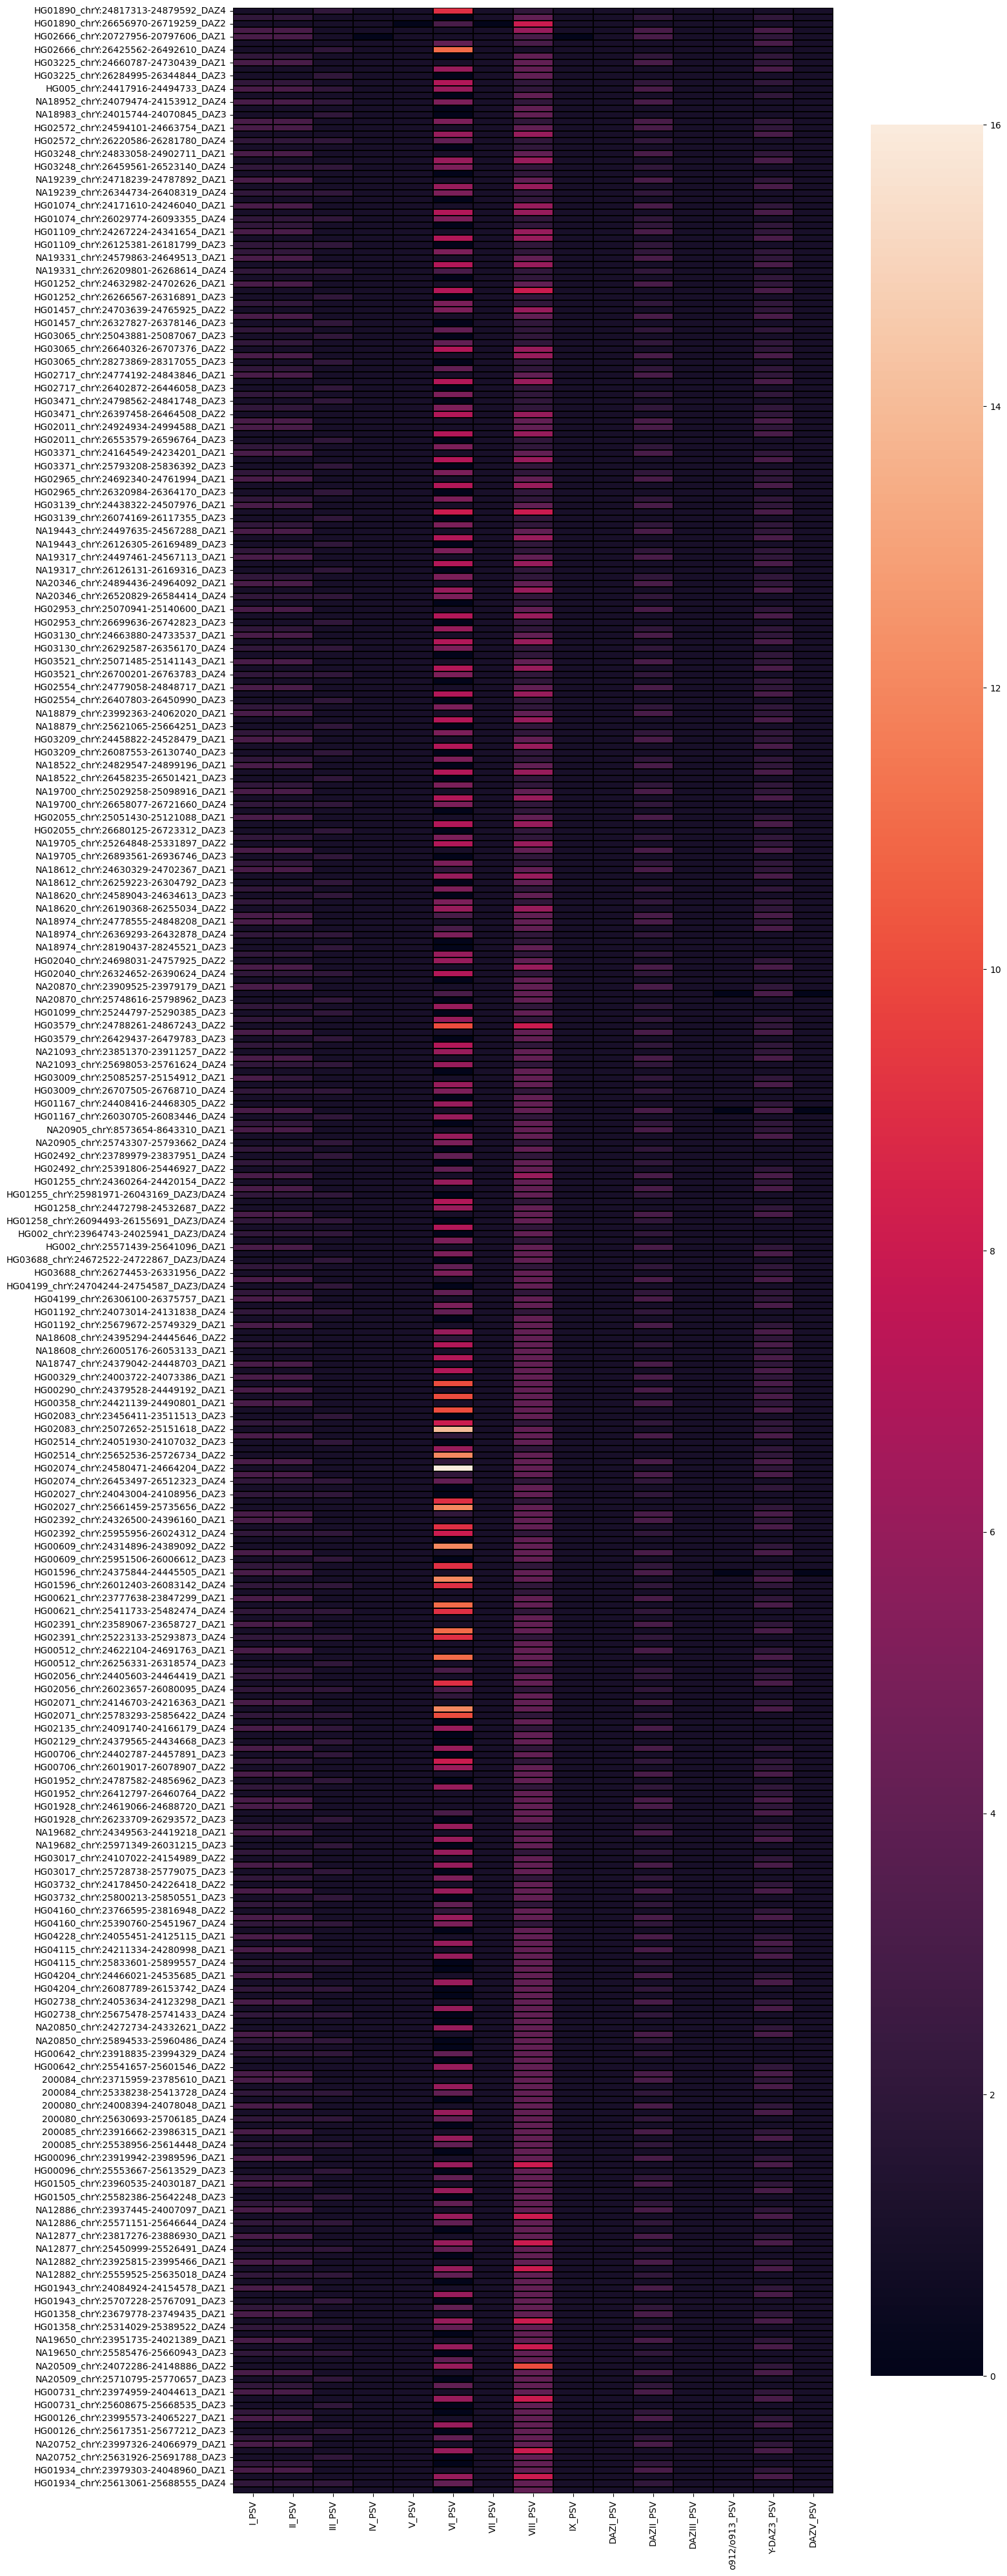

In [26]:
plt.figure(figsize=(15, 50)) 
sns.heatmap(psvDF_sorted3,square=False,
            linewidths=0.1,
            linecolor='black')
#plt.savefig("/psv_heatmap.pdf", dpi=300, bbox_inches="tight")

<Axes: >

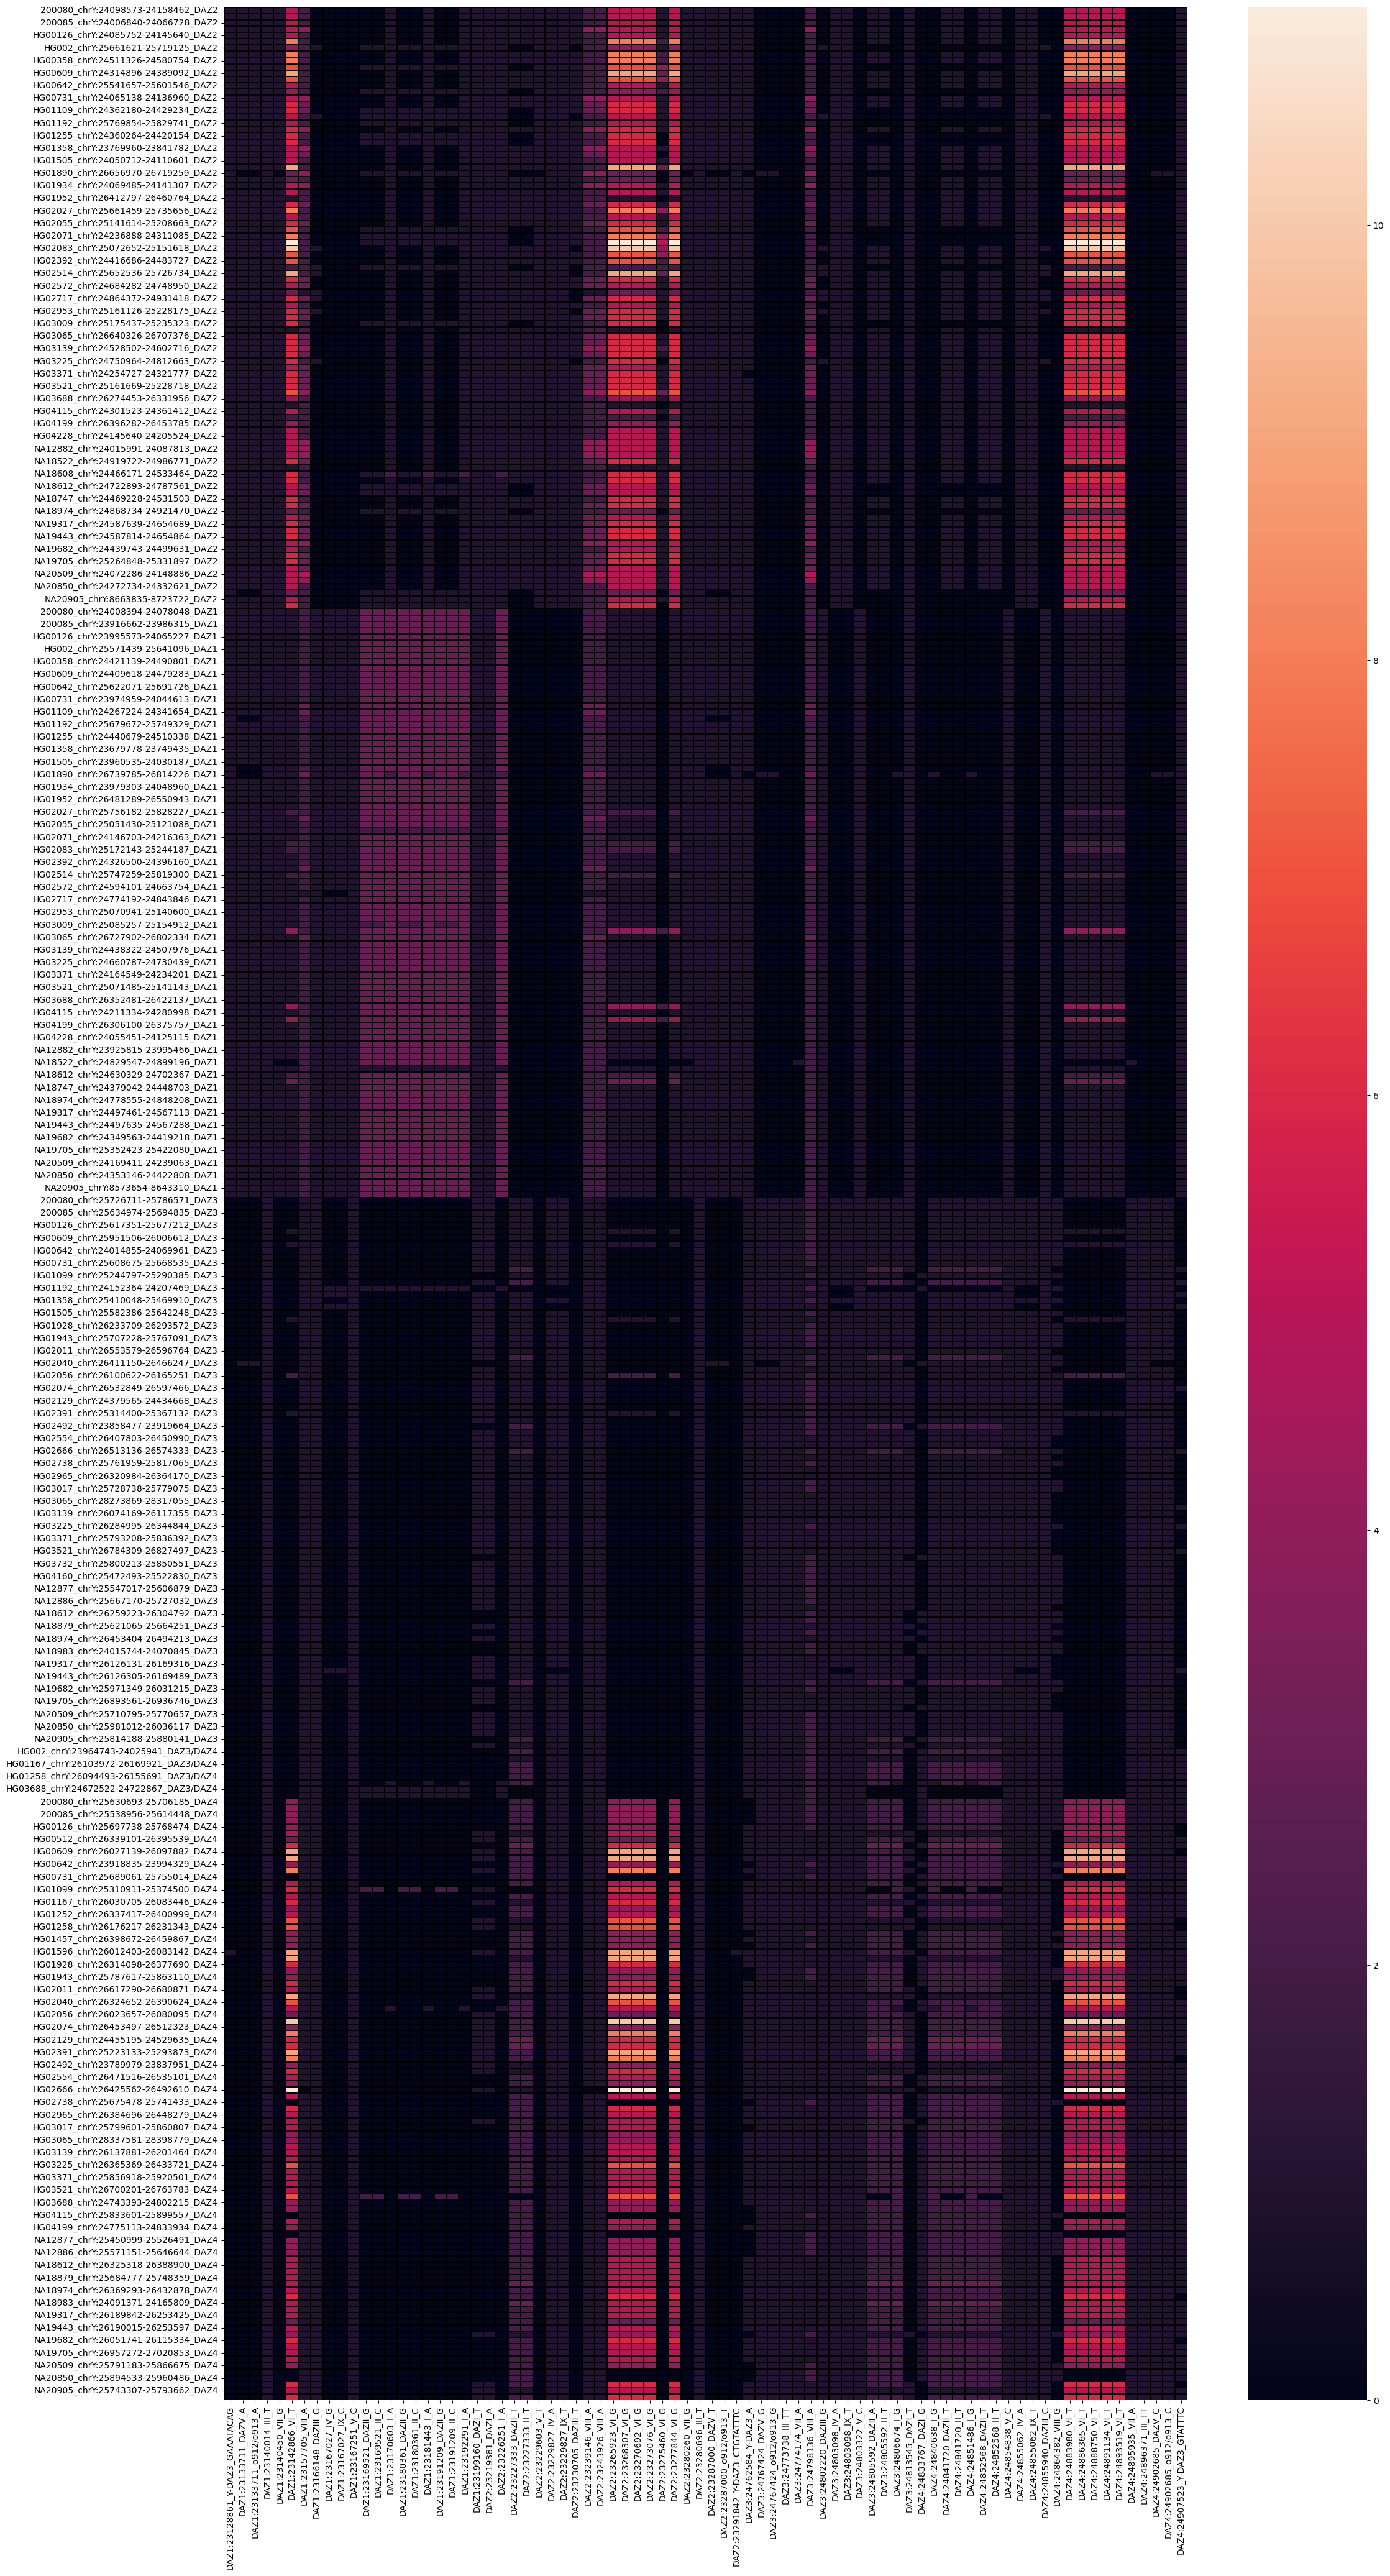

In [27]:
plt.figure(figsize=(25, 50)) 
sns.heatmap(psvAlleleDF4,square=False,
            linewidths=0.1,
            linecolor='black')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DAZ_Specific/psv_DAZ_heatmap-Jan222026.pdf", dpi=300, bbox_inches="tight")

In [28]:
color_dict = {
    0: 'brown',
    1: 'black',
    2: 'orange',
    3:'cyan',
    4:'yellow'
}

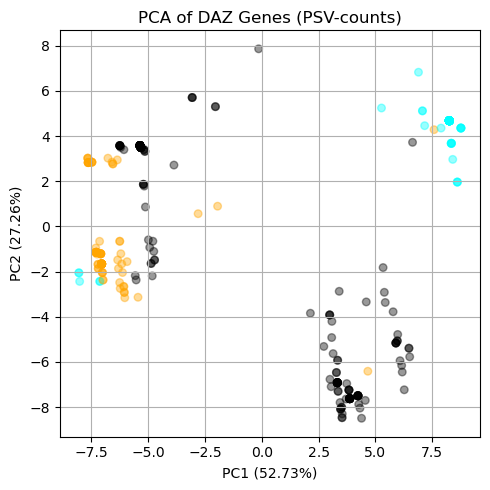

In [106]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

baddotColor={x:color_dict[myDF2.at[x,'RRMs']] for x in psvAlleleDF2.index}
badSamples = [x for x,y in baddotColor.items() if y =='brown' or y =='yellow']
psvAlleleDF3 = psvAlleleDF2.loc[[x for x in psvAlleleDF2.index if x not in badSamples]].copy()
color_dict = {
    0: 'brown',
    1: 'black',
    2: 'orange',
    3:'cyan',
    4:'yellow'
}
dotColor={x:color_dict[myDF2.at[x,'RRMs']] for x in psvAlleleDF3.index}

colors = [dotColor[x] for x in psvAlleleDF3.index]
# 1. Use only numeric columns
X = psvAlleleDF3.select_dtypes(include=['number']).copy()
X = X.fillna(0)

# 2.
X_log = np.log1p(X)   # log(1 + count)

# 3. 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 4. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    index=psvAlleleDF3.index,
    columns=['PC1', 'PC2']
)

# 5. Plot
plt.figure(figsize=(5,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=30,c=colors, alpha=0.4,)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA of DAZ Genes (PSV-counts)")
plt.grid(True)
plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DAZ_Specific/DAZ_psv_PCA_Jan222026.pdf", bbox_inches="tight")#
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DAZ_Specific/DAZ_psv_PCA_Jan222026.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
color_dict2 = {
    'DAZ1': 'orange',
    'DAZ2': 'green',
    'DAZ3': 'blue',
    'DAZ4':'red',
    'DAZ3/DAZ4':'magenta'
}

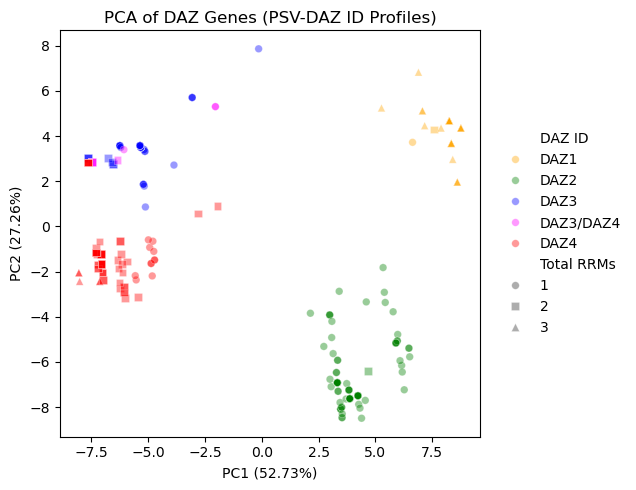

In [46]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

psvAlleleDF3 = psvAlleleDF2.copy()
color_dict2 = {
    'DAZ1': 'orange',
    'DAZ2': 'green',
    'DAZ3': 'blue',
    'DAZ4':'red',
    'DAZ3/DAZ4':'magenta'
}


dotColor={x:color_dict2[myDF2.at[x,'MaxCount']] for x in psvAlleleDF3.index}
colors = [dotColor[x] for x in psvAlleleDF3.index]

shape_dict = {
    1: 'o',
    2: 's',
    3:'^',
}

dotShape={x:shape_dict[myDF2.at[x,'RRMs']] for x in psvAlleleDF3.index}
shapes = [dotShape[x] for x in psvAlleleDF3.index]

X = psvAlleleDF3.select_dtypes(include=['number']).copy()
X = X.fillna(0)

X_log = np.log1p(X)   # log(1 + count)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 4. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    index=psvAlleleDF3.index,
    columns=['PC1', 'PC2']
)

# 5. Plot
plt.figure(figsize=(5,5))

import seaborn as sns

plot_df = pca_df.copy()
plot_df["DAZ ID"] = myDF2.loc[plot_df.index, "MaxCount"]
plot_df["Total RRMs"] = myDF2.loc[plot_df.index, "RRMs"]
hue_order = ["DAZ1", "DAZ2", "DAZ3", "DAZ3/DAZ4","DAZ4"]
style_order = [1, 2, 3]

ax=sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="DAZ ID",
    hue_order=hue_order,
    style="Total RRMs",
    palette=color_dict2,
    markers=shape_dict,
    s=30,
    alpha=0.4
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA of DAZ Genes (PSV-DAZ ID Profiles)")
plt.tight_layout()
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DAZ_Specific/DAZ_submission/DAZ_psv_PCA_Classifications-Jan220206.pdf", bbox_inches="tight")
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DAZ_Specific/DAZ_submission/DAZ_psv_PCA_Classifications-Jan220206.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
psvAlleleDF3

,DAZ1:23128861_Y-DAZ3_GAAATACAG,DAZ1:23133711_DAZV_A,DAZ1:23133711_o912/o913_A,DAZ1:23140014_III_T,DAZ1:23140450_VII_G,DAZ1:23142866_VI_T,DAZ1:23157705_VIII_A,DAZ1:23166148_DAZIII_G,DAZ1:23167027_IV_G,DAZ1:23167027_IX_C,...,DAZ4:24883980_VI_T,DAZ4:24886365_VI_T,DAZ4:24888750_VI_T,DAZ4:24891134_VI_T,DAZ4:24893519_VI_T,DAZ4:24895935_VII_A,DAZ4:24896371_III_TT,DAZ4:24902685_DAZV_C,DAZ4:24902685_o912/o913_C,DAZ4:24907523_Y-DAZ3_GTATTTC
200080_chrY:24098573-24158462,1,1,1,1,1,5,2,0,0,0,...,5,5,5,5,5,0,0,0,0,1
200084_chrY:23806135-23866021,1,1,1,1,1,5,2,0,0,0,...,5,5,5,5,5,0,0,0,0,1
200085_chrY:24006840-24066728,1,1,1,1,1,5,2,0,0,0,...,5,5,5,5,5,0,0,0,0,1
HG00096_chrY:24010121-24081942,1,1,1,1,1,5,4,0,0,0,...,5,5,5,5,5,0,0,0,0,1
HG00126_chrY:24085752-24145640,1,1,1,1,1,5,2,0,0,0,...,5,5,5,5,5,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA20752_chrY:25712314-25778268,0,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,1,1,1,1,1
NA20850_chrY:25894533-25960486,0,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,1,1,1,1,1
NA20870_chrY:25819488-25883079,0,0,0,1,0,6,1,1,0,0,...,6,6,6,6,6,1,1,1,1,0
NA20905_chrY:25743307-25793662,0,0,0,1,0,5,1,1,0,0,...,5,5,5,5,5,1,1,1,1,1
